## Cluster-Mass based Permutation testing in Julia

- Step 1: load and check adjacency matrix
- Step 2: fit model on data
- Step 3: run cluster-mass permutation test
- Step 4: plotting

In [85]:
import Pkg
#Pkg.activate("/data/p_02865/tools/UnfoldStats.jl/docs")
Pkg.activate("..")
Pkg.instantiate()


using UnfoldSim
using MAT
using CairoMakie
using Random
using Statistics
using UnfoldMixedModels
using UnfoldStats
using DataFrames
using MixedModelsPermutations
using UnfoldMakie
using Logging
using ClusterDepth
using CSV

ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
lmm_permutations = ext.lmm_permutations
#get_lmm_statistic = ext.get_lmm_statistic


#include("../read_adjacency.jl")
include("../cluster_mass_test.jl")


  Activating project at `~/Desktop/ClusterComputation`


spatiotemporal_cluster_pvalues (generic function with 1 method)

In [66]:
# 1. Positions CSV
positions_df = CSV.read("channel_positions_Magda.csv", DataFrame;
                     types=[String, Float64, Float64])

# 2.adjacency CSV
adj_df = CSV.read("adjacency_Magda.csv", DataFrame; stringtype=String, strict=false)
electrode_labels = adj_df.Column1
adjacency = select!(adj_df, Not(1))
adjacency = Matrix(adjacency)
adjacency = Bool.(adjacency)

59×59 BitMatrix:
 1  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  1  1  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0     1  0  0  0  0  0  0  1  1  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  1  0  0  0  0  1
 ⋮              ⋮              ⋮        ⋱           ⋮              ⋮        
 0  0  0  0  0  0  0  0  0  0  0  0  1  …  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0 

## 1. Correctly format the EEG data
- **60 subjects** (20 per group)
- **3 time points**
- **3 dependent variables** 1/f, alpha and beta (should all be in seperate data arrays)

In [67]:
electrode_labels

59-element Vector{String}:
 "Fp1"
 "Fp2"
 "F3"
 "F4"
 "C3"
 "C4"
 "P3"
 "P4"
 "O1"
 "O2"
 ⋮
 "TP7"
 "TP8"
 "PO7"
 "PO8"
 "Fpz"
 "AFz"
 "FCz"
 "CPz"
 "POz"

In [68]:
# read the data
data_eeg = Array{Union{Missing,Float64}}(undef, 59, 1, 180)

for (i, channel) in enumerate(electrode_labels)
    df_fooof = CSV.read("/Users/mg/Desktop/MOVE/resting_state/fooof/$(channel)_fooof_params.csv", DataFrame)
    # here one would need to filter to get rid of timepoints or groups etc. (and also adjust evts in next cell!)
    #eeg_vector = df_fooof.alpha_PW_absolute_periodic_log
    eeg_vector = df_fooof.beta_PW_absolute_periodic_log
    #eeg_vector = df_fooof.exponent
    #print(length(eeg_vector))
    data_eeg[i, 1, :] = eeg_vector
end

data_eeg = Float64.(coalesce.(data_eeg, NaN))  # replace "missing" with "nan" so it can be Float64
data_eeg

59×1×180 Array{Float64, 3}:
[:, :, 1] =
 -13.240308977937813
 -13.277087506303545
 -13.005161537935527
 -13.267557487050656
 -12.57075240398084
 -12.797952371276804
 -12.890730492421108
 -12.764830841215344
 -12.326108671041535
 -12.802325376176567
   ⋮
 -12.648901343414975
 -12.87988124607997
 -12.209495597820139
 -12.634401211828987
 -13.193223209554008
 -13.086556972504944
 -12.93947480393179
 -12.965619515752602
 -12.742405071332692

[:, :, 2] =
 -13.115390646527807
 -12.741018598209367
 -12.91092119322191
 -13.175381859306556
 -12.502447521986381
 -12.660308344016574
 -12.825366361744331
 -12.738835581049479
 -12.155216957597865
 -12.73711176531758
   ⋮
 -12.738778405684808
 -12.542391936035594
 -12.039654216539788
 -12.565480819978546
 -13.160362792355079
 -13.073796026597636
 -12.873410656494734
 -12.814570123626506
 -12.672529557265552

[:, :, 3] =
 -12.620312998894958
 -12.513130078395983
 -12.880573828514612
 -12.848274233879698
 -12.651957372992452
 -12.573161964643305
 -13.

In [69]:
# format the independent variables for the mixed models
df_behavior = CSV.read("/Users/mg/Desktop/MOVE/MOVE_Analysis_MG/KINARM/behavioral_measure.csv", DataFrame)
rename!(df_behavior, :VP => :Subject )
df_evts = select(df_behavior, [:Subject, :Behavior, :Group])
evts = repeat(df_evts, inner = 3)
evts.Time = repeat(1:3, 60)
evts.Subject = string.(evts.Subject)  # Subject needs to be categorical for model
evts

Row,Subject,Behavior,Group,Time
,String,Float64,String1,Int64
1,1,0.0623471,C,1
2,1,0.0623471,C,2
3,1,0.0623471,C,3
4,2,-6.97687,A,1
5,2,-6.97687,A,2
6,2,-6.97687,A,3
7,3,-2.00111,M,1
8,3,-2.00111,M,2
9,3,-2.00111,M,3


## 2. fit model

In [70]:
eltype(contr)

Pair{Symbol, EffectsCoding}

In [71]:
# Fit mass-univariate LMM
times = [1]  # how many time points are we working with?

# set contrast to effectsCoding for Group to compare against mean
contr = Dict(
   :Group => EffectsCoding(base="C", levels=["A", "C", "M"]) # for ANOVA output, base does not matter in EffectsCoding; EffectsCoding compares to the mean
   #:Group => DummyCoding(base="M")
 )

println("Fitting LMM at each channel...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ Group * Time + (1+Time | Subject)), # @formula(0 ~ Behavior * Group * Time + (1+Time | Subject))
            times,

        ),
    ],
    evts,
    data_eeg;
    contrasts = contr,
);

Fitting LMM at each channel...
  0.085110 seconds (64.78 k allocations: 1.933 MiB)


In [72]:
# Extract coefficients for the stimtype effect
coefs = coeftable(m)
unique(coefs.coefname)

# Show available columns
#println("Available columns: $(names(coefs))")


6-element Vector{String}:
 "(Intercept)"
 "Group: A"
 "Group: M"
 "Time"
 "Group: A & Time"
 "Group: M & Time"

In [73]:
# choose the effect to look at
coefficient = 4  # what effect

coefficient_name = unique(coefs.coefname)[coefficient]

"Time"

Rows for stimtype: 118
Unique channels: 59
Unique times: 1

=== Uncorrected Effects (before permutation) ===
Max |z|: 4.43
Peak location: channel C1 at t = 1.0s
Samples with |z| > 2.0: 17 / 59
Samples with |z| > 1.96: 17 (uncorrected p < 0.05)


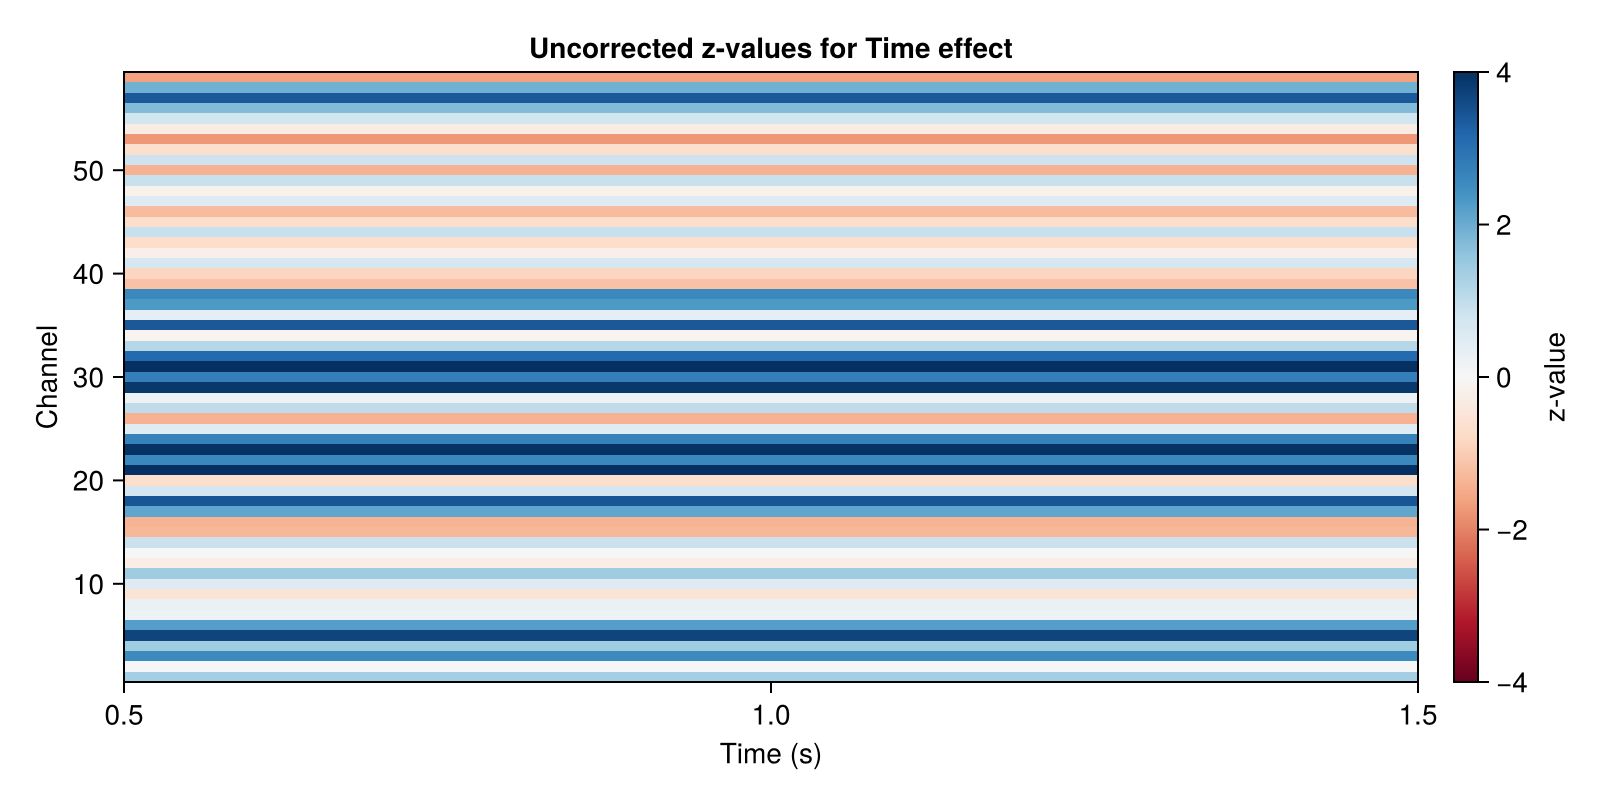

In [74]:
# Check uncorrected effects before running permutation test

# Filter for coefficient
coef_stimtype = filter(r -> r.coefname == coefficient_name, coefs)
println("Rows for stimtype: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(coef_stimtype.time))
println("Unique channels: $(length(unique_channels))")
println("Unique times: $(length(unique_times))")

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate]
stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
z_vec = estimate_vec ./ stderror_vec

coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
z_summary = combine(
    groupby(coef_stimtype, [:channel, :time]),
    :z => (x -> mean(filter(!isnan, x))) => :z
)
sort!(z_summary, [:channel, :time])

# Replace NaN with 0 for visualization
z_summary.z = replace(z_summary.z, NaN => 0.0)

# Reshape z-values to channels × times
n_ch_coef = length(unique_channels)
n_t_coef = length(unique_times)
z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 1.96)
n_sig_uncorrected = sum(abs.(z_vals) .> 1.96)  # Paul used 2.0 here
max_z = maximum(abs.(z_vals))
peak_idx = argmax(abs.(z_vals))
peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

println("\n=== Uncorrected Effects (before permutation) ===")
println("Max |z|: $(round(max_z, digits=2))")
println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of z-values
fig_z = Figure(size = (800, 400))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected z-values for Time effect",
    xlabel = "Time (s)",
    ylabel = "Channel")
hm = heatmap!(ax_z, collect(unique_times), 1:n_ch_coef, z_vals', colormap = :RdBu, colorrange = (-4, 4))
Colorbar(fig_z[1, 2], hm, label = "z-value")
fig_z

In [75]:
electrode_labels[peak_ch]

"C1"

## 3. Perform cluster-mass permutation test

In [76]:
# --- Cluster-mass permutation test using explicit functions ---

#coefficient = 4  # what effect
n_permutations = 50  # Reduced for dev; use 500-1000 for real analyses
threshold = 1.96

time_selection = 1:length(times)

# Generate permutation distribution
permuted = lmm_permutations(MersenneTwister(42), m, data_eeg, coefficient;
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection
)


59×1×50 Array{Float64, 3}:
[:, :, 1] =
 -1.7518353995316616
 -0.6439607105258212
  0.18482696832130602
  0.11077778738148497
  0.8293714037455809
  1.068852630541594
 -0.7225793621836913
 -0.5533158079779766
 -0.38959426402240627
 -0.13281536859702683
  ⋮
 -1.0641426843182427
 -1.4312083282856274
 -0.679824196180612
  0.04100340140072827
 -3.3692263880348006
 -0.9563900506893666
  0.017060766078423658
 -2.8551786133914274
 -0.26353295611359423

[:, :, 2] =
 -1.3463711130852716
 -0.4017899737640422
  0.17872193313640392
  1.0870595755500532
  2.3336854970530125
  1.988744205589237
  0.8798949869363992
  1.128783287074019
  1.5044853795101385
  1.4526392431820525
  ⋮
  1.3401738706058035
  0.5847144285765382
  1.3452502222045997
  1.0309387368838054
 -0.9350191873303952
  0.36862245048615794
  0.9866478158961589
  1.3887057653005197
  1.0987639833539764

[:, :, 3] =
 -1.2916548195612194
 -0.5165997523213469
  1.6989176918198028
  0.6678596994214198
  1.0965014030846556
  1.05561681942127

In [77]:
extrema(z_vals)  # check these values with C3 calculation, second valus is C1 most likely for alpha and beta, first value for exponent (this is correct for effect over time)

(-1.7502177636773273, 4.431734551106316)

# to do: 
## 1. check how permutation works (unfold function) "lmm_permutations"
## 2. make the same thing for linear models!

### transform in .jl and make loop so ALL coefficients are calculated for a given model (save output in what kind of form?)
### calculate submodels (only two time points for example)

In [78]:
z_vals

59×1 adjoint(::Matrix{Float64}) with eltype Float64:
  1.3880417662544162
  0.04339202327287851
  2.564037471134386
  1.4049507053113235
  3.704755142090246
  2.2298401752245285
  0.2044775025222183
  0.27173814155183496
 -0.5663586210737751
  0.5368476573711753
  ⋮
  0.8486803989172754
 -0.6642622371035006
 -1.7502177636773273
 -0.3215548424196569
  0.7729247233698895
  1.7679302618838866
  3.3968538347127577
  1.9429912198739614
 -1.6362908476970404

Significant cluster IDs: Int64[]
p-value of cluster: 0.058823529411764705


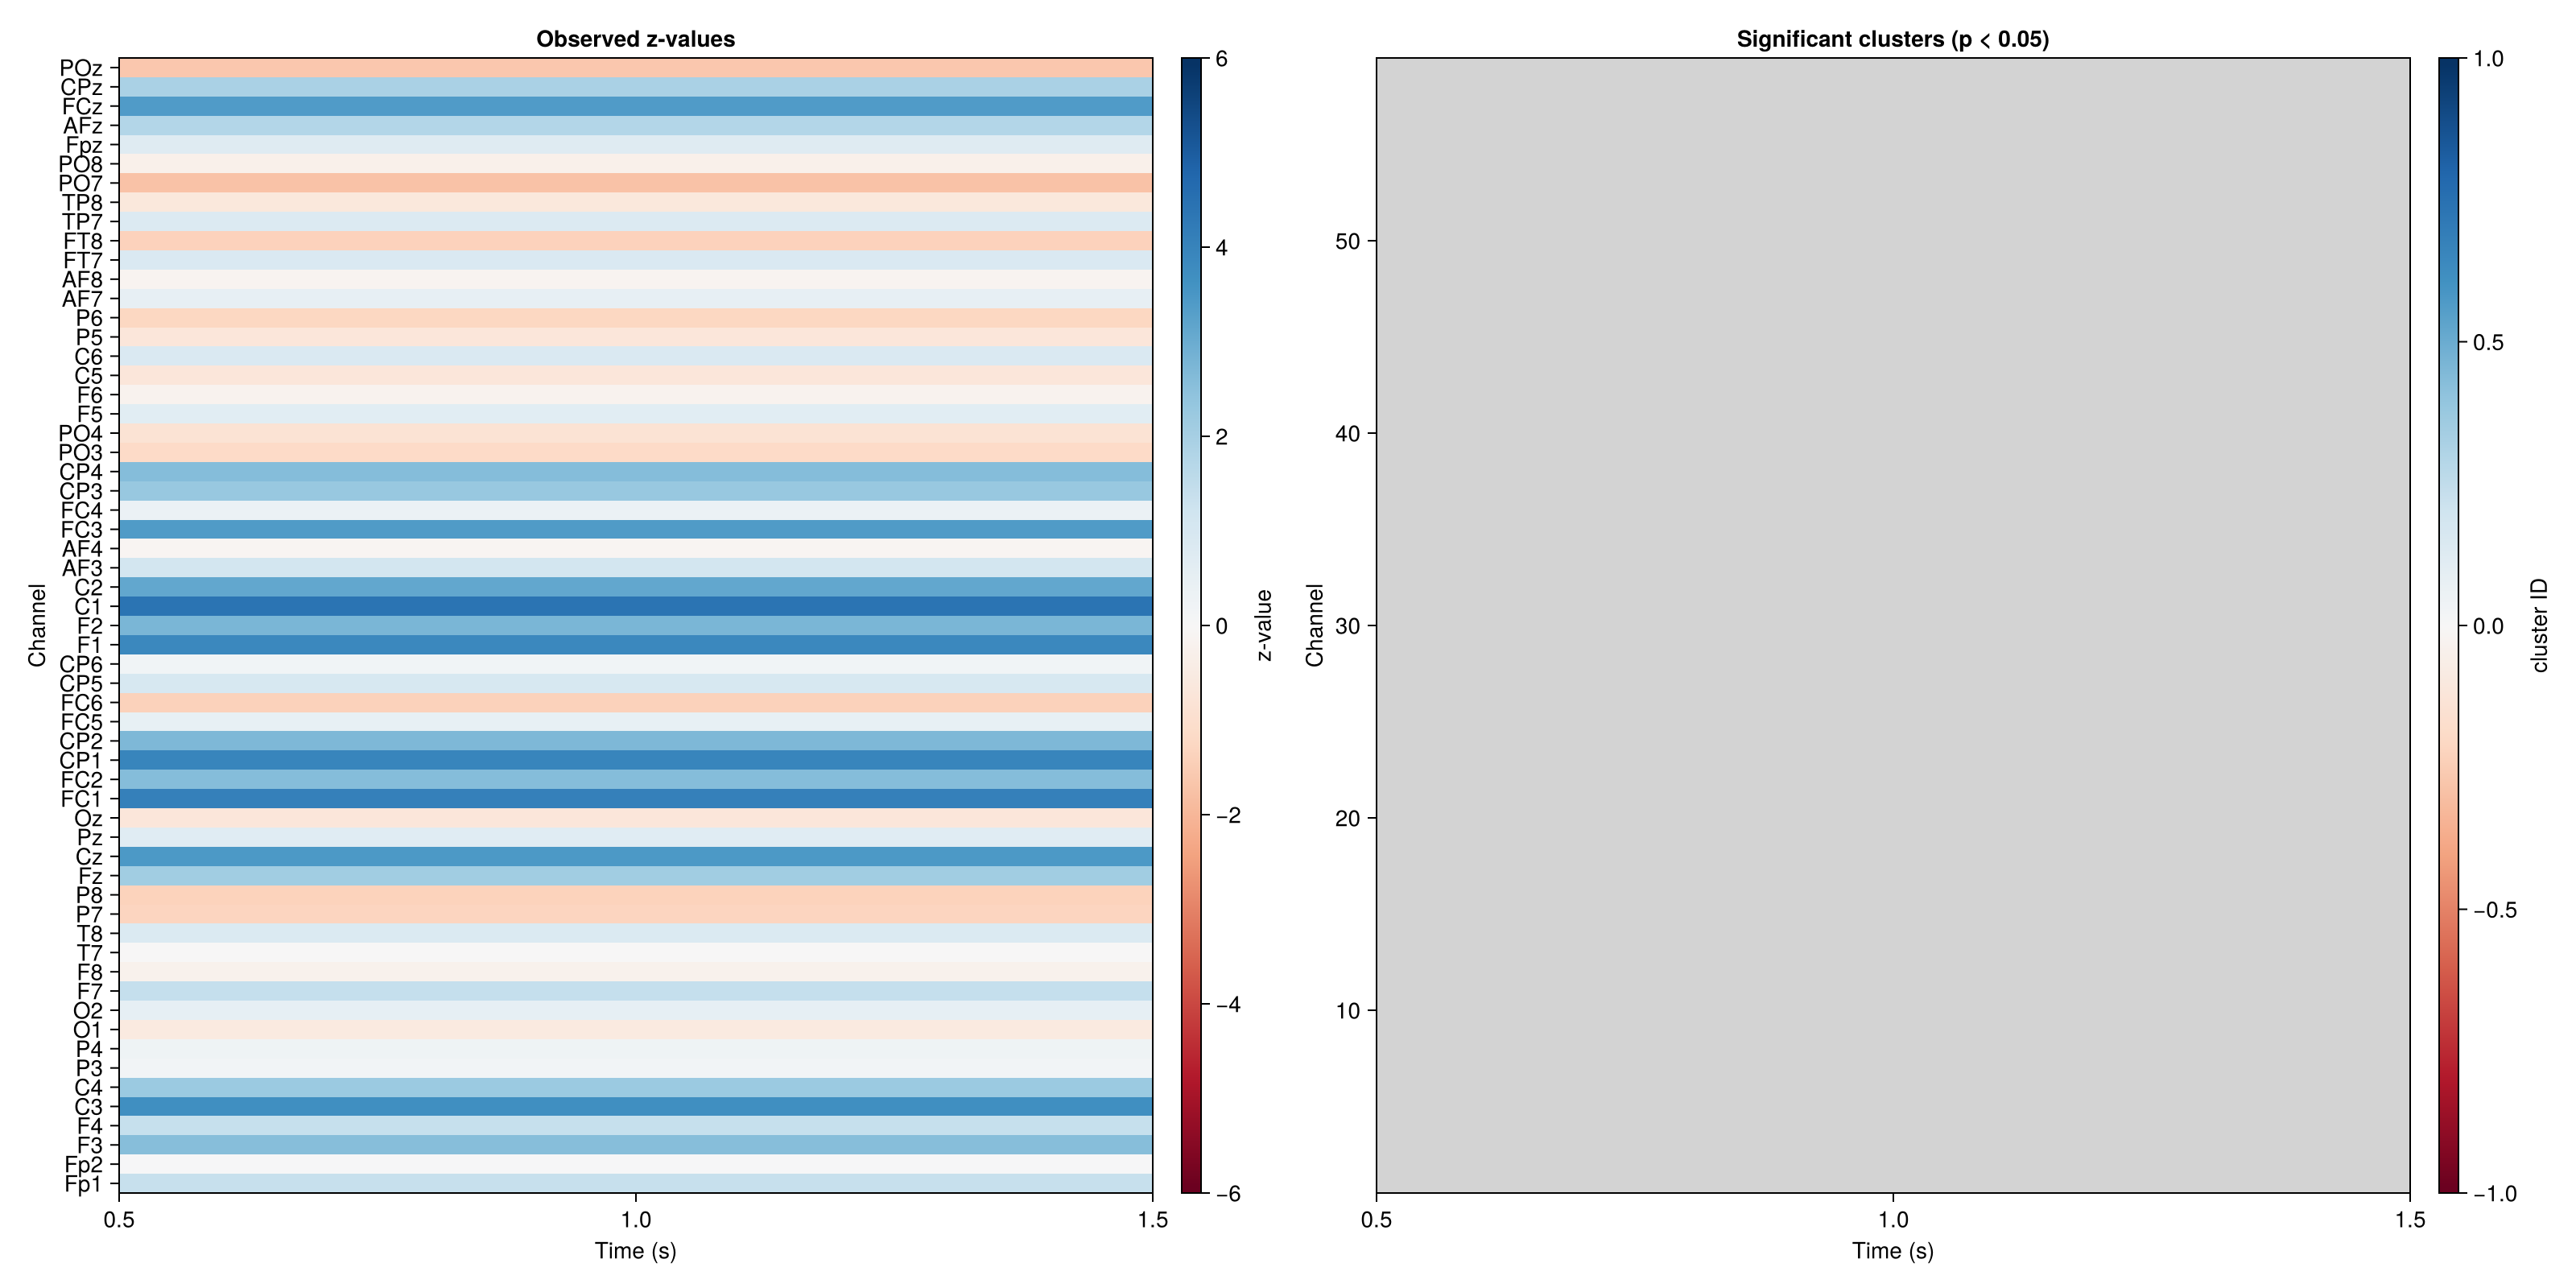

In [79]:
# compare observed data to permuted data
n_channels = 59

observed = z_vals
pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")
println("p-value of cluster: $(minimum(pvals_clustermass))")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, electrode_labels))
hm1 = heatmap!(ax1, collect(times), 1:n_channels, z_vals', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel")
hm2 = heatmap!(ax2, collect(times), 1:n_channels, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

## 4. Plotting

In [80]:
# calculate electrode positions for topoplots
n = size(adjacency, 1)
coords = Dict(row.ch_name => (row.x, row.y) for row in eachrow(positions_df))

xs = [get(coords, electrode_labels[i], (0.0, 0.0))[1] for i in 1:n]
ys = [get(coords, electrode_labels[i], (0.0, 0.0))[2] for i in 1:n]

pos2d = [Point2f(xs[i], ys[i]) for i in 1:n]

59-element Vector{Point{2, Float32}}:
 [0.31910187, 0.9022613]
 [0.60451525, 0.9022613]
 [0.26805818, 0.70231706]
 [0.6555589, 0.70231706]
 [0.23090428, 0.4630553]
 [0.69271284, 0.4630553]
 [0.26805818, 0.22379355]
 [0.6555589, 0.22379355]
 [0.31910187, 0.023849286]
 [0.60451525, 0.023849286]
 ⋮
 [0.022602523, 0.32034862]
 [0.90101457, 0.32034862]
 [0.19036429, 0.08944435]
 [0.7332528, 0.08944435]
 [0.46180853, 0.9248639]
 [0.46180853, 0.7760589]
 [0.46180853, 0.57594186]
 [0.46180853, 0.35016876]
 [0.46180853, 0.11926448]

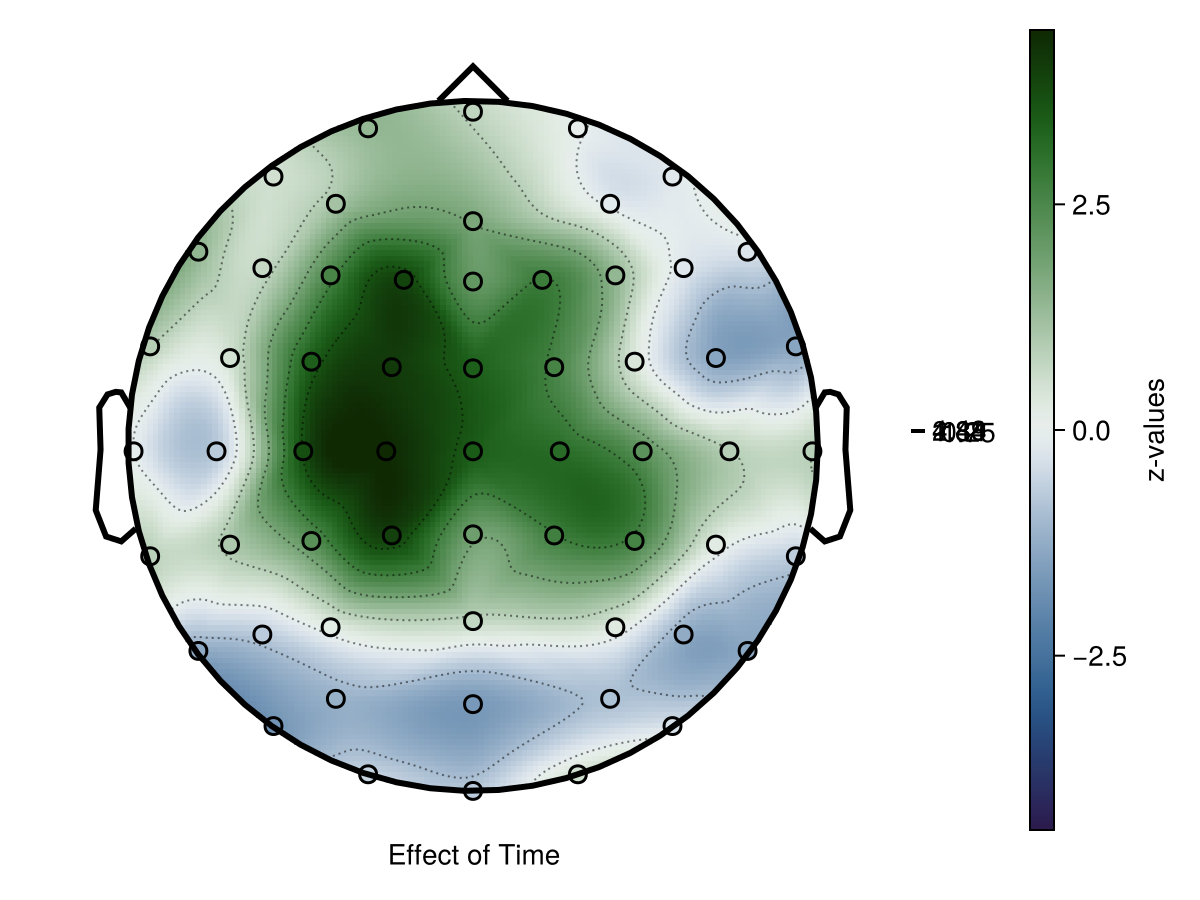

In [81]:
# create topoplot

#pos3d = hart.electrodes["pos"][channel_idx, :]  # 32x3 matrix for selected channels
#pos2d = [Point2f(pos3d[i,1], pos3d[i,2]) for i in 1:size(pos3d,1)]  # convert to 2D points for topoplot
sig_mask = pvals_clustermass .< 0.05

cluster_data = copy(z_vals)
plot_data = reshape(cluster_data, size(cluster_data)..., 1)  # reshape for plotting (or use df)

min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))  # get the limits

#cluster_data[.!sig_mask] .= 0.0  # Set non-significant to zero (or NaN)
# Ensure correct orientation: time x channels
df = DataFrame(
    :estimate => vec(cluster_data),  # no transpose, time is slow axis, channels is fast axis
    :channel => repeat(1:size(cluster_data, 1), outer = size(cluster_data, 2)),
    :time => repeat(1:size(cluster_data, 2), inner = size(cluster_data, 1))
)

# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]

marker_colors = [is_sig ? :yellow : :black for is_sig in sig_ch] # Set marker color: orange for significant, black for others
strokes = [is_sig ? 3 : 1.5 for is_sig in sig_ch]
sizes = fill(12, 59)

fig = Figure()

plot_topoplot!(
    fig[1, 1],
    plot_data[:, 1, 1];  # df
    positions = pos2d,
    #mapping=(; y=:estimate),
    axis = (; xlabel = "Effect of $(coefficient_name)"),
    visual = (; colormap = :cork, contours = true, colorrange = (-limit, limit)),  # this is a hack
    #colorbar = (; limits = (-2.3, 2.3)),
    #colorbar = (; colorrange = (-2.3, 2.3)),
    #colorbar = (; height = 150, label = "z-values"), #, limits = (-4.5, 4.5)),
    colorbar = (;  label = "", width=1, height=1), # height
    topo_attributes = (;
        label_scatter = (;
            markersize = sizes,
            strokecolor = marker_colors,
            strokewidth = strokes)),
    )

Colorbar(fig[1, 2], colorrange = (-limit, limit), colormap = :cork, label = "z-values", height = 400)  # hack because colorbar does not match what I specify
#fig.colorrange = (-2.3, 2.3)
fig


In [82]:
min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))
colorrange = (-limit, limit)

(-4.431734551106316, 4.431734551106316)

Averaging across 1 time points
Any NaN in avg_topo: false


┌ Warning: No significant time points found; falling back to averaging across all times
└ @ Main /Users/mg/Desktop/ClusterComputation/notebooks/tutorial_notebook_Magda.ipynb:18


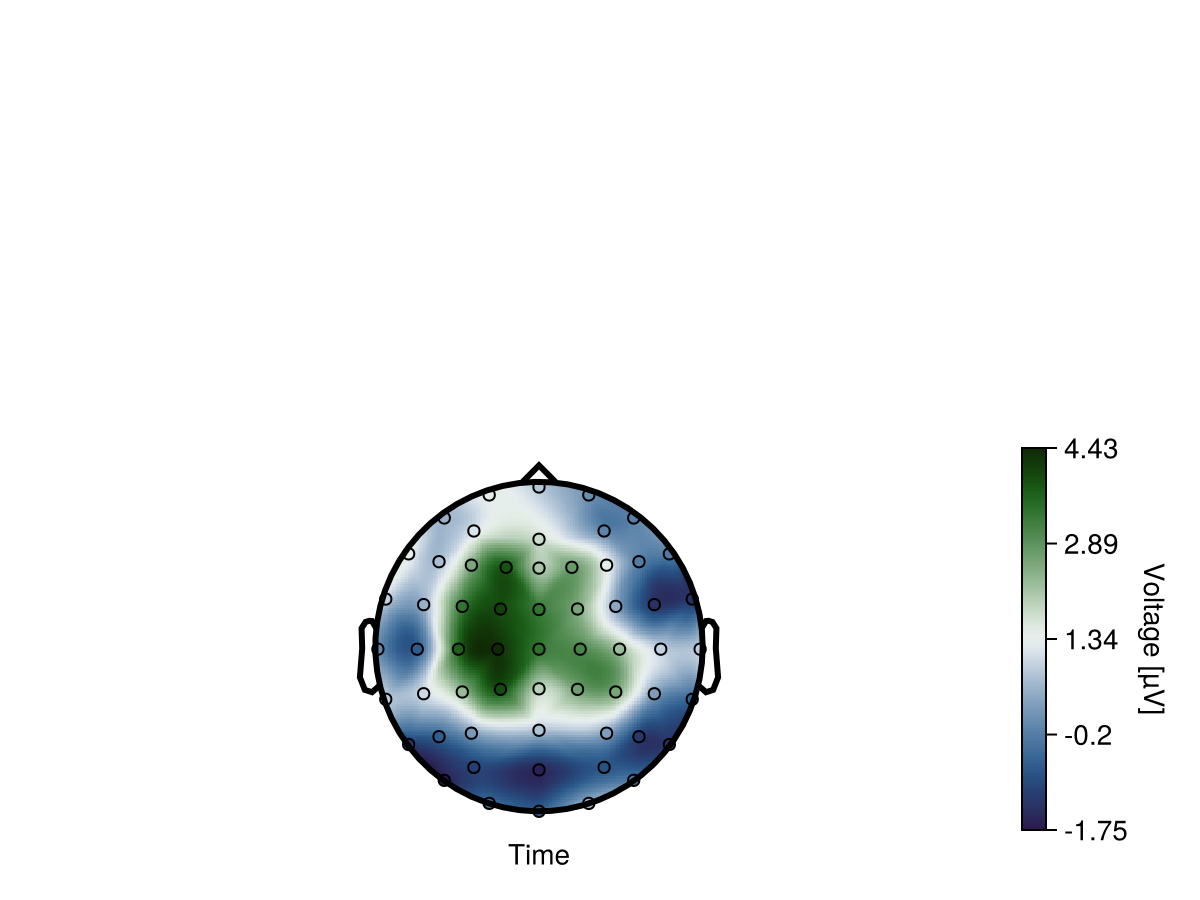

In [83]:
# old plotting code

f = Figure()
# Average ERP across all trials for each channel and time
erp = mean(cluster_data; dims=3)[:,:,1]  # (channels x times)
df_erp = DataFrame(
    :amplitude => vec(erp),
    :channel => repeat(1:size(erp, 1), outer = size(erp, 2)),
    :time => repeat(1:size(erp, 2), inner = size(erp, 1))
)
#plot_butterfly!(f[1, 1:2], df_erp; positions = pos2d, mapping=(; y=:amplitude))
# Find significant time points (p < 0.05)
# sig_mask is channels x times, so get time indices where any channel is significant
sig_time_bool = vec(any(sig_mask, dims=1))
unique_times = sort(unique(df_erp.time))
sig_times = unique_times[sig_time_bool]
if isempty(sig_times)
    @warn "No significant time points found; falling back to averaging across all times"
    sig_times = unique_times
end
println("Averaging across $(length(sig_times)) time points")
# Compute average topography robustly (avoid averaging over empty selection)
avg_topo = Float64[]
for ch in 1:n_channels
    sel = (df_erp.channel .== ch) .& in.(df_erp.time, Ref(sig_times))
    vals = df_erp.amplitude[sel]
    if isempty(vals)
        push!(avg_topo, NaN)
    else
        push!(avg_topo, mean(vals))
    end
end
println("Any NaN in avg_topo: ", any(isnan, avg_topo))
if any(isnan, avg_topo)
    @warn "avg_topo contains NaNs for channels: $(findall(isnan, avg_topo))"
end
# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]
# Set marker color: red for significant, gray for others
marker_colors = [is_sig ? :orange : :black for is_sig in sig_ch]

strokes = [is_sig ? 2 : 1 for is_sig in sig_ch]

#colors = fill(:orange, 59)
sizes = fill(8, 59)

df = DataFrame(:amplitude => avg_topo, :channel => 1:n_channels)

plot_topoplot!(
    f[2, 1],
    df;
    positions = pos2d,
    mapping=(; y=:amplitude),
    visual = (; colormap = :cork, contours = false),
    #colorbar = (; limits = (-2.3, 2.3)),
    #colorbar = (; colorrange = (-2.3, 2.3)),
    topo_attributes = (;
        label_scatter = (;
            markersize = sizes,
            strokecolor = marker_colors,
            strokewidth = strokes)),
    )

f